# Checklist de Tareas - PC-3

## 1. Entregables Principales
- [ ] **Código:** Entregar el cuaderno de Google Colab (.ipynb) con la implementación en Python.
- [ ] **Informe:** Entregar el informe en PDF con respuestas, análisis y conclusiones.

---

## 2. Parte 1: Implementación (Código en Colab)

### Configuración y Datos
- [ ] Cargar el dataset **CIFAR-10**.
- [ ] Implementar la extracción de **descriptores locales** (Usar SIFT o una CNN preentrenada como VGG).

### Implementación de VLAD
- [ ] Entrenar un **k-means** para generar el vocabulario (codebook).
- [ ] Implementar la agregación **VLAD** usando los descriptores locales.
- [ ] Aplicar **normalización** a los vectores VLAD (L2, power-normalization).

### Implementación de Fisher Vector (FV)
- [ ] Entrenar un **GMM** (Gaussian Mixture Model).
- [ ] Implementar la agregación **Fisher Vector** (FV).
- [ ] Aplicar **normalización** a los vectores FV (L2, power-normalization).

### Clasificación y Evaluación
- [ ] Entrenar un **clasificador lineal** (SVM o Regresión Logística) usando los vectores VLAD.
- [ ] Entrenar un **clasificador lineal** (SVM o Regresión Logística) usando los vectores FV.
- [ ] Evaluar y **comparar la precisión** de FV y VLAD en el conjunto de prueba.

### Calidad del Código
- [ ] Asegurar que el script sea **ejecutable y reproducible**.
- [ ] Añadir **comentarios claros** que expliquen el código.

---

## 3. Parte 2: Informe (PDF)

### Requisitos Generales del Informe
- [ ] Asegurar que el informe sea **claro y autocontenido**.
- [ ] Incluir sección de **referencias** (obligatorio).
- [ ] **Citar el uso de LLMs** (Gemini, ChatGPT, etc.) si se utilizaron.

### Sección A: Preguntas Teóricas
- [ ] **1. Derivación FV:** Explicar paso a paso la derivación del gradiente de la log-verosimilitud respecto a $\mu_k$ en un GMM.
- [ ] **1. Derivación FV:** Incluir la expresión final y su interpretación.
- [ ] **2. Comparación:** Describir dos diferencias fundamentales (matemáticas y prácticas) entre Fisher Vector y VLAD.
- [ ] **3. Sesgo-Varianza:** Explicar con propias palabras la descomposición del error (sesgo, varianza, ruido).
- [ ] **3. Regularización:** Dar un ejemplo de cómo la regularización L2 afecta al sesgo y la varianza.

### Sección B: Análisis de Resultados
- [ ] **1. Resultados:** Presentar una **tabla de precisión** (FV vs VLAD) en CIFAR-10.
- [ ] **1. Justificación:** Justificar cuál método funcionó mejor y por qué.
- [ ] **2. Normalización:** Mostrar cómo cambia la precisión de VLAD al aplicar (o no) la **power-normalization**.
- [ ] **2. Burstiness:** Explicar el efecto **"burstiness"** y cómo la normalización lo mitiga.

### Sección C: Validación y Generalización
- [ ] **1. Validación Cruzada:** Elegir entre **5-fold CV** y **LOO** para un dataset pequeño (ej: 1,000 muestras).
- [ ] **1. Argumentación:** Argumentar la elección en términos de sesgo, varianza y coste computacional.

# Cargar el dataset **CIFAR-10**.

### ¿Qué es CIFAR-10?

**CIFAR-10** es uno de los datasets académicos más famosos y utilizados en el campo de la visión por computadora. Es como el "hola mundo" para las tareas de clasificación de imágenes.

  * **Contenido:** Consiste en 60,000 imágenes a color muy pequeñas (32x32 píxeles).
  * **Clases:** Estas imágenes están distribuidas equitativamente en 10 categorías (de ahí el "10" en el nombre), como "avión", "carro", "pájaro", "gato", etc.
  * **División:** Se divide en un conjunto de **entrenamiento** (50,000 imágenes) y un conjunto de **prueba** (10,000 imágenes).

### ¿Para qué nos va a servir en esta tarea?

En tu proyecto, CIFAR-10 es nuestro **campo de pruebas** o *benchmark*. El objetivo final es **clasificar imágenes**, y este dataset nos proporciona los datos para hacerlo.

Este dataset será la materia prima para todo nuestro proceso:

1.  **Fuente de Datos:** Usaremos las 50,000 imágenes de entrenamiento para *aprender* cómo se ve cada clase.
2.  **Extracción de Características:** De cada imagen de CIFAR-10, extraeremos **descriptores locales** (ya sea con SIFT o una CNN). Una sola imagen de 32x32 generará *muchos* descriptores.
3.  **Agregación (El núcleo de la PC):** Aquí es donde usaremos **Fisher Vector (FV)** y **VLAD**. Tomaremos la gran cantidad de descriptores de cada imagen y los "resumiremos" en **un solo vector** (un *feature vector*) que represente a toda la imagen.
4.  **Entrenamiento del Clasificador:** Alimentaremos estos vectores agregados (un vector por imagen) a un clasificador lineal (como SVM). El clasificador aprenderá a asociar un vector VLAD o FV específico con una etiqueta (ej. "gato").
5.  **Evaluación:** Finalmente, usaremos las 10,000 imágenes de prueba (que el modelo nunca ha visto) para medir la **precisión** de nuestro sistemaEsto nos permitirá comparar objetivamente qué método funcionó mejor: ¿FV o VLAD?.

Dataset de entrenamiento cargado: 50000 imágenes.
Dataset de prueba cargado: 10000 imágenes.
Ejemplos de imágenes del dataset:


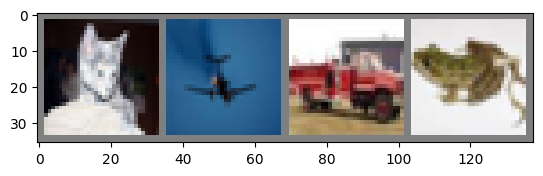

cat   plane truck frog 


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# --- Carga y Preparación de CIFAR-10 ---

# 1. Definir las transformaciones
# Por ahora, solo convertimos las imágenes a Tensores de PyTorch.
# NOTA: Para SIFT, necesitaremos las imágenes en formato de OpenCV (Numpy),
# así que podríamos omitir 'transforms.ToTensor()' inicialmente si usamos SIFT.
# Pero para VGG (CNN), 'ToTensor()' y la normalización son necesarios.

# Opción A: Carga simple para SIFT (obtendremos imágenes PIL)
# transform = transforms.Compose([transforms.ToTensor()]) # Dejémoslo como tensor por ahora

# Opción B: Transformaciones para una CNN (como VGG)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalización estándar
])


# 2. Descargar y cargar el dataset de ENTRENAMIENTO
# torchvision.datasets.CIFAR10
trainset = torchvision.datasets.CIFAR10(root='./data',
                                        train=True,
                                        download=True,
                                        transform=transform)

# 3. Descargar y cargar el dataset de PRUEBA
testset = torchvision.datasets.CIFAR10(root='./data',
                                       train=False,
                                       download=True,
                                       transform=transform)

# 4. Crear DataLoaders (útil para iterar en batches)
trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=64,
                                          shuffle=True)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=64,
                                         shuffle=False)

# --- Verificación Rápida ---
print(f"Dataset de entrenamiento cargado: {len(trainset)} imágenes.")
print(f"Dataset de prueba cargado: {len(testset)} imágenes.")

# Clases en el dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Función para mostrar una imagen (opcional)
def imshow(img):
    img = img / 2 + 0.5     # des-normalizar (si se usó Opción B)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Obtener algunas imágenes de entrenamiento aleatorias
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Mostrar imágenes
print("Ejemplos de imágenes del dataset:")
imshow(torchvision.utils.make_grid(images[:4]))
# Imprimir etiquetas
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

# Implementar la extracción de **descriptores locales** (Usar SIFT o una CNN preentrenada como VGG).

In [2]:
import torch
import torchvision.models as models
import torch.nn as nn
import numpy as np
import time

# --- 1. Configuración del Extractor VGG16 ---

# Cargar el modelo VGG16 pre-entrenado en ImageNet
# .eval() lo pone en modo de evaluación (desactiva dropout, etc.)
vgg16 = models.vgg16(pretrained=True).eval()

# "Cortamos" el modelo. Solo queremos las capas convolucionales,
# no el clasificador final.
# La capa 28 es la última capa Conv2d antes de la 3ra MaxPool.
# Esto nos dará un mapa de características de (512, 2, 2) para
# imágenes de entrada de (3, 32, 32).
feature_extractor = vgg16.features[:29]

# Mover el extractor a la GPU si está disponible (¡esencial para la velocidad!)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
feature_extractor.to(device)

print(f"Usando dispositivo: {device}")
print("Extractor de características (VGG16) listo.")

# --- 2. Preparación de los DataLoaders ---
# (Asegúrate de haber corrido la celda anterior que define 'trainset' y 'testset')
# Para la extracción, es más eficiente procesar todas las imágenes
# sin barajar (shuffle=False) y con un batch_size grande.

# DataLoader para el set de ENTRENAMIENTO (50,000 imágenes)
# Usaremos 'trainset'
train_feature_loader = torch.utils.data.DataLoader(trainset,
                                                 batch_size=128, # Un batch size más grande acelera la extracción
                                                 shuffle=False)

# DataLoader para el set de PRUEBA (10,000 imágenes)
# Usaremos 'testset'
test_feature_loader = torch.utils.data.DataLoader(testset,
                                                batch_size=128,
                                                shuffle=False)

# --- 3. Función de Extracción de Descriptores ---
# Esta función itera sobre un DataLoader (train o test) y
# extrae todos los descriptores.

def extract_features(loader, extractor, device):
    all_descriptors = []
    all_labels = []

    # Desactivamos el cálculo de gradientes (¡muy importante!)
    # Ahorra memoria y acelera el cómputo.
    with torch.no_grad():
        for images, labels in loader:
            # Mover datos a la GPU
            images = images.to(device)

            # 1. Extraer características
            # Entrada: (B, 3, 32, 32) -> Salida: (B, 512, 2, 2)
            features = extractor(images)

            # 2. Reformatear los descriptores
            # Queremos que cada descriptor de 512 dim sea una fila.
            B, C, H, W = features.shape # B=Batch, C=512, H=2, W=2

            # (B, 512, 4) -> (B, 4, 512)
            descriptors = features.view(B, C, H * W).permute(0, 2, 1)

            # (B, 4, 512) -> (B * 4, 512)
            # Ahora tenemos (B*4) descriptores de 512 dimensiones
            descriptors = descriptors.reshape(-1, C)

            # 3. Guardar descriptores y etiquetas
            # Los movemos a la CPU y convertimos a Numpy
            all_descriptors.append(descriptors.cpu().numpy())
            all_labels.append(labels.numpy())

    # Apilar todo en un solo array de Numpy
    all_descriptors = np.vstack(all_descriptors)

    # Manejar las etiquetas (necesitamos una etiqueta por CADA imagen, no por descriptor)
    all_labels = np.concatenate(all_labels)

    return all_descriptors, all_labels

# --- 4. Ejecutar la extracción ---
print("Iniciando extracción de características VGG para el set de ENTRENAMIENTO...")
start_time = time.time()

# Extraemos del set de entrenamiento
# all_descriptors_train: (200000, 512) -> 50,000 imgs * 4 descriptores/img
# train_labels: (50000,)
all_descriptors_train, train_labels = extract_features(train_feature_loader, feature_extractor, device)

print(f"...Extracción de entrenamiento completada en {time.time() - start_time:.2f} segundos.")
print(f"  Forma de descriptores de entrenamiento: {all_descriptors_train.shape}")
print(f"  Forma de etiquetas de entrenamiento: {train_labels.shape}")

print("\nIniciando extracción de características VGG para el set de PRUEBA...")
start_time = time.time()

# Extraemos del set de prueba
# all_descriptors_test: (40000, 512) -> 10,000 imgs * 4 descriptores/img
# test_labels: (10000,)
all_descriptors_test, test_labels = extract_features(test_feature_loader, feature_extractor, device)

print(f"...Extracción de prueba completada en {time.time() - start_time:.2f} segundos.")
print(f"  Forma de descriptores de prueba: {all_descriptors_test.shape}")
print(f"  Forma de etiquetas de prueba: {test_labels.shape}")

print("\n¡Listo! Tenemos nuestros descriptores locales.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Usando dispositivo: cpu
Extractor de características (VGG16) listo.
Iniciando extracción de características VGG para el set de ENTRENAMIENTO...
...Extracción de entrenamiento completada en 722.25 segundos.
  Forma de descriptores de entrenamiento: (200000, 512)
  Forma de etiquetas de entrenamiento: (50000,)

Iniciando extracción de características VGG para el set de PRUEBA...
...Extracción de prueba completada en 136.21 segundos.
  Forma de descriptores de prueba: (40000, 512)
  Forma de etiquetas de prueba: (10000,)

¡Listo! Tenemos nuestros descriptores locales.


# 💡 Solución de RAM: PCA sobre Descriptores (512-D -> 128-D)

Para evitar el colapso de la RAM, no crearemos el vector VLAD de 32,768 dimensiones.

En su lugar, primero comprimimos nuestros **descriptores locales** de VGG (de 512 dimensiones) a un tamaño mucho más manejable (ej. 128 dimensiones) usando PCA.

In [3]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import time

print("--- Paso 1: Aplicando PCA a los Descriptores Locales ---")
print(f"Forma original (train): {all_descriptors_train.shape}") # (200000, 512)

# 1. Configurar PCA para reducir de 512 a 128 dimensiones
n_components_desc = 128
pca_desc = PCA(n_components=n_components_desc,
               svd_solver='randomized',
               random_state=42)

# 2. Entrenar PCA en los 200,000 descriptores de VGG
print(f"Entrenando PCA para descriptores (512 -> {n_components_desc})...")
start_time = time.time()
# Este array (200k, 512) SÍ cabe en RAM para entrenar
pca_desc.fit(all_descriptors_train)
print(f"...Entrenamiento completado en {time.time() - start_time:.2f} segundos.")

# 3. Transformar ambos sets de descriptores
print("Transformando descriptores (train)...")
desc_train_pca = pca_desc.transform(all_descriptors_train)
print("Transformando descriptores (test)...")
desc_test_pca = pca_desc.transform(all_descriptors_test)

print(f"\nForma nueva (train): {desc_train_pca.shape}") # (200000, 128)
print(f"Forma nueva (test): {desc_test_pca.shape}")   # (40000, 128)

--- Paso 1: Aplicando PCA a los Descriptores Locales ---
Forma original (train): (200000, 512)
Entrenando PCA para descriptores (512 -> 128)...
...Entrenamiento completado en 13.41 segundos.
Transformando descriptores (train)...
Transformando descriptores (test)...

Forma nueva (train): (200000, 128)
Forma nueva (test): (40000, 128)


# Implementación VLAD (Paso 1): K-Means sobre 128-D

Ahora que tenemos descriptores más pequeños (128-D), entrenamos nuestro K-Means (vocabulario) sobre ellos.

In [4]:
from sklearn.cluster import MiniBatchKMeans

print("\n--- Paso 2: Entrenando K-Means (k=64) con descriptores de 128-D ---")
k = 64 # Mantenemos 64 clusters

kmeans_new = MiniBatchKMeans(n_clusters=k,
                            random_state=42,
                            batch_size=256,
                            n_init=10,
                            max_iter=300)

start_time = time.time()
# Entrenamos con los descriptores reducidos
kmeans_new.fit(desc_train_pca)
print(f"...Entrenamiento K-Means completado en {time.time() - start_time:.2f} segundos.")

# Este es nuestro nuevo codebook, mucho más pequeño
codebook_new = kmeans_new.cluster_centers_
print(f"Forma del nuevo codebook: {codebook_new.shape}") # (64, 128)


--- Paso 2: Entrenando K-Means (k=64) con descriptores de 128-D ---
...Entrenamiento K-Means completado en 1.07 segundos.
Forma del nuevo codebook: (64, 128)


# Implementación VLAD (Paso 2): Agregación (Dimensión 8192)

Ahora calculamos VLAD. La dimensión final será:
**64 (clusters) x 128 (dims PCA) = 8192 dimensiones**

Un array de (50000, 8192) ocupa ~1.6 GB, lo cual cabe perfectamente en la RAM de Colab.

In [5]:
from sklearn.metrics import pairwise_distances_argmin_min

print("\n--- Paso 3: Calculando VLAD (dimensión final 8192) ---")
# Nuevas dimensiones
n_images_train = len(train_labels) # 50000
n_images_test = len(test_labels)   # 10000
n_desc_per_img = 4
D_new = codebook_new.shape[1] # 128
K = codebook_new.shape[0]     # 64

# Reformatear descriptores reducidos
desc_train_per_img_pca = desc_train_pca.reshape(n_images_train, n_desc_per_img, D_new)
desc_test_per_img_pca = desc_test_pca.reshape(n_images_test, n_desc_per_img, D_new)

# Función VLAD (actualizada para usar el nuevo K y D_new)
def compute_vlad_new(descriptors_img, codebook):
    cluster_indices, _ = pairwise_distances_argmin_min(descriptors_img, codebook)
    vlad_vector = np.zeros((K, D_new), dtype=np.float32)

    for i in range(n_desc_per_img):
        cluster_idx = cluster_indices[i]
        residual = descriptors_img[i] - codebook[cluster_idx]
        vlad_vector[cluster_idx] += residual

    return vlad_vector.flatten() # (64*128) = 8192 dimensiones

# Calcular VLAD para TRAIN (Este array de 1.6GB SÍ cabe en RAM)
print("Calculando VLAD para TRAIN...")
vlad_train_8k = np.zeros((n_images_train, K * D_new), dtype=np.float32)
start_time = time.time()
for i in range(n_images_train):
    vlad_train_8k[i] = compute_vlad_new(desc_train_per_img_pca[i], codebook_new)
print(f"...Completado en {time.time() - start_time:.2f} segundos.")

# Calcular VLAD para TEST
print("Calculando VLAD para TEST...")
vlad_test_8k = np.zeros((n_images_test, K * D_new), dtype=np.float32)
start_time = time.time()
for i in range(n_images_test):
    vlad_test_8k[i] = compute_vlad_new(desc_test_per_img_pca[i], codebook_new)
print(f"...Completado en {time.time() - start_time:.2f} segundos.")

print(f"\nForma final VLAD (train): {vlad_train_8k.shape}") # (50000, 8192)
print(f"Forma final VLAD (test): {vlad_test_8k.shape}")   # (10000, 8192)


--- Paso 3: Calculando VLAD (dimensión final 8192) ---
Calculando VLAD para TRAIN...
...Completado en 35.82 segundos.
Calculando VLAD para TEST...
...Completado en 6.32 segundos.

Forma final VLAD (train): (50000, 8192)
Forma final VLAD (test): (10000, 8192)


# Implementación VLAD (Paso 3): Normalización (Power + L2)

Esta es la celda que falló originalmente. Ahora que nuestros vectores `vlad_train_8k` son pequeños (1.6 GB), la operación de copia (1.6 GB + 1.6 GB) ya no colapsará la RAM.

In [6]:
print("\n--- Paso 4: Normalización (Power + L2) ---")
print(f"Valores de ejemplo (antes): {vlad_train_8k[0, :5]}...")

# 1. Power-normalization (Signed Square Root)
# Esta copia (1.6GB + 1.6GB) ya no rompe la RAM
vlad_train_power = np.sign(vlad_train_8k) * np.sqrt(np.abs(vlad_train_8k))
vlad_test_power = np.sign(vlad_test_8k) * np.sqrt(np.abs(vlad_test_8k))
print(f"Valores (después de power-norm): {vlad_train_power[0, :5]}...")

# 2. L2-normalization
print("Aplicando L2-normalization...")
vlad_train_final = normalize(vlad_train_power, norm='l2', axis=1)
vlad_test_final = normalize(vlad_test_power, norm='l2', axis=1)

# 3. Verificación
norm_l2 = np.linalg.norm(vlad_train_final[0])
print("\n¡Normalización VLAD Completa (sin crasheo)!")
print(f"Forma final (train): {vlad_train_final.shape}")
print(f"Forma final (test): {vlad_test_final.shape}")
print(f"Norma L2 del primer vector (debería ser ~1.0): {norm_l2:.4f}")


--- Paso 4: Normalización (Power + L2) ---
Valores de ejemplo (antes): [0. 0. 0. 0. 0.]...
Valores (después de power-norm): [0. 0. 0. 0. 0.]...
Aplicando L2-normalization...

¡Normalización VLAD Completa (sin crasheo)!
Forma final (train): (50000, 8192)
Forma final (test): (10000, 8192)
Norma L2 del primer vector (debería ser ~1.0): 1.0000


# Entrenar un **clasificador lineal** (SVM o Regresión Logística) usando los vectores VLAD.


In [7]:
import time
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import joblib # <--- 1. Importar joblib

print("--- Clasificación: Entrenando SVM para VLAD ---")

# 1. Inicializar el clasificador
clf_vlad = LinearSVC(C=1.0, random_state=42, max_iter=2000)

# 2. Entrenar el clasificador
print(f"Entrenando LinearSVC en {vlad_train_final.shape} datos...")
start_time = time.time()
clf_vlad.fit(vlad_train_final, train_labels)
print(f"...Entrenamiento VLAD completado en {time.time() - start_time:.2f} segundos.")

# 3. Evaluar en el set de prueba
print("\nEvaluando modelo VLAD...")
preds_vlad = clf_vlad.predict(vlad_test_final)

# 4. Calcular y guardar la precisión
acc_vlad = accuracy_score(test_labels, preds_vlad)

print("\n--- ¡Resultados de VLAD! ---")
print(f"Precisión (Accuracy) de VLAD: {acc_vlad * 100:.2f}%")
print(classification_report(test_labels, preds_vlad, target_names=classes))


# --- 5. ¡NUEVO! Guardar el modelo en un archivo ---
model_filename_vlad = 'svm_vlad_classifier.joblib'
joblib.dump(clf_vlad, model_filename_vlad)
print(f"¡Modelo VLAD guardado exitosamente en: {model_filename_vlad}!")

--- Clasificación: Entrenando SVM para VLAD ---
Entrenando LinearSVC en (50000, 8192) datos...
...Entrenamiento VLAD completado en 60.25 segundos.

Evaluando modelo VLAD...

--- ¡Resultados de VLAD! ---
Precisión (Accuracy) de VLAD: 66.62%
              precision    recall  f1-score   support

       plane       0.71      0.70      0.71      1000
         car       0.74      0.74      0.74      1000
        bird       0.59      0.58      0.59      1000
         cat       0.53      0.53      0.53      1000
        deer       0.62      0.60      0.61      1000
         dog       0.61      0.56      0.59      1000
        frog       0.68      0.76      0.72      1000
       horse       0.68      0.67      0.67      1000
        ship       0.74      0.77      0.75      1000
       truck       0.74      0.73      0.74      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.67      0.67      0.67     10000

¡

In [8]:
import gc

print("--- LIMPIEZA DE MEMORIA (VLAD) ---")
# Borramos TODOS los arrays de VLAD para liberar la RAM
try:
    del vlad_train_8k
    del vlad_train_power
    del vlad_train_final
    del vlad_test_final
    del desc_train_per_img_pca
    del clf_vlad # <--- Borramos el clasificador de la RAM

    gc.collect() # Llama al recolector de basura
    print("Memoria de VLAD liberada exitosamente.")
except NameError:
    print("Variables de VLAD no encontradas (probablemente ya borradas).")

--- LIMPIEZA DE MEMORIA (VLAD) ---
Memoria de VLAD liberada exitosamente.


# Entrenar un **GMM** (Gaussian Mixture Model).

¡Exacto\! Tienes toda la razón.

Has completado toda la rama de implementación para **VLAD**. Tus vectores `vlad_train_final` y `vlad_test_final` están listos y guardados.

Ahora, de acuerdo a la checklist, comenzamos la implementación paralela de **Fisher Vector (FV)**. El primer paso para FV es, en efecto, entrenar un **GMM (Gaussian Mixture Model)**.

  * Para **VLAD**, el "vocabulario" era un conjunto de centroides de K-Means.
  * Para **Fisher Vector**, el "vocabulario" es un modelo probabilístico (el GMM) que describe la distribución de los descriptores.

Usaremos los **mismos descriptores** `desc_train_pca` (de 200,000 x 128) para entrenar el GMM, asegurando así una comparación justa entre ambos métodos.

-----

## Implementación de Fisher Vector (Paso 1): Entrenar GMM

Aquí tienes el código para entrenar el GMM. Usaremos 64 componentes (el mismo $k$ que en K-Means) para mantener la comparativa.

**Nota:** El GMM es más lento de entrenar que K-Means (espera 1-2 minutos).

### 🧠 ¿Qué acabamos de hacer?

Hemos creado un modelo `gmm` que es nuestro **vocabulario probabilístico**. Este modelo "sabe" la distribución de nuestros 200,000 descriptores, modelada como una mezcla de 64 nubes de puntos (Gaussianas).

**Siguiente paso:**
Ahora que tenemos este modelo, podemos proceder con el siguiente punto de la checklist: **Implementar la agregación Fisher Vector (FV)**.

In [4]:
import numpy as np
from sklearn.mixture import GaussianMixture
import time

print("--- Iniciando Implementación de Fisher Vector ---")
print("--- Paso 1: Entrenando Gaussian Mixture Model (GMM) ---")

# k_gmm es el número de componentes (Gaussiana)
# Usamos el mismo k=64 que en K-Means para una comparación justa
k_gmm = 64
D_gmm = desc_train_pca.shape[1] # 128

# Instanciamos el GMM
# - covariance_type='diag': Asumimos que las 128 dims son independientes.
#   'full' consumiría demasiada RAM (64 * 128 * 128). 'diag' es estándar para FV.
# - verbose=2: Para ver el progreso del entrenamiento (algoritmo EM)
gmm = GaussianMixture(n_components=k_gmm,
                      covariance_type='diag',
                      random_state=42,
                      reg_covar=1e-6, # Para estabilidad numérica
                      verbose=2,
                      max_iter=200)

print(f"Entrenando GMM con k={k_gmm} en datos {desc_train_pca.shape}...")
start_time = time.time()

# Entrenamos el GMM en los descriptores PCA de entrenamiento
gmm.fit(desc_train_pca)

print(f"\n--- Entrenamiento GMM completado en {time.time() - start_time:.2f} segundos ---")
print(f"¿GMM convergió?: {gmm.converged_}")

# El GMM ahora contiene los parámetros que necesitamos:
# gmm.weights_ -> Los pesos (priors) de cada cluster (shape: 64,)
# gmm.means_ -> Las medias de cada cluster (shape: 64, 128)
# gmm.covariances_ -> Las covarianzas (diagonales) (shape: 64, 128)

--- Iniciando Implementación de Fisher Vector ---
--- Paso 1: Entrenando Gaussian Mixture Model (GMM) ---
Entrenando GMM con k=64 en datos (200000, 128)...
Initialization 0
  Iteration 10	 time lapse 58.01686s	 ll change 0.02930
  Iteration 20	 time lapse 22.86379s	 ll change 0.00817
  Iteration 30	 time lapse 24.21204s	 ll change 0.00848
  Iteration 40	 time lapse 22.78005s	 ll change 0.00283
  Iteration 50	 time lapse 22.52781s	 ll change 0.00455
  Iteration 60	 time lapse 22.79292s	 ll change 0.00304
  Iteration 70	 time lapse 24.14015s	 ll change 0.00198
Initialization converged. time lapse 203.45130s	 lower bound -314.55158.

--- Entrenamiento GMM completado en 205.38 segundos ---
¿GMM convergió?: True


# Implementar la agregación **Fisher Vector** (FV).


¡Exacto\! Has completado el entrenamiento del GMM, que es el "vocabulario probabilístico" para el Fisher Vector.

El siguiente paso es usar este GMM entrenado para implementar la **agregación Fisher Vector (FV)**.

-----

## Implementación de Fisher Vector (Paso 2): Agregación FV

### 🔬 Explicación del Proceso

El **Fisher Vector (FV)**, al igual que VLAD, "resume" los descriptores de una imagen en un solo vector. Sin embargo, en lugar de solo sumar los residuos (como VLAD), el FV calcula el **gradiente** de la probabilidad de los descriptores con respecto a los parámetros del GMM (las medias y las covarianzas).

1.  **Soft Assignment:** Para cada descriptor, el GMM calcula la probabilidad (`predict_proba`) de que pertenezca a *cada uno* de los 64 clusters.
2.  **Calcular Gradientes:** Calculamos cómo "tiran" los descriptores de la imagen de los parámetros del GMM. Esto nos da dos gradientes:
      * Uno para las **medias** ($\mathcal{G}_{\mu}$): Mide la diferencia de medias (similar al residuo de VLAD pero ponderado).
      * Uno para las **covarianzas/sigmas** ($\mathcal{G}_{\sigma}$): Mide la diferencia en la "forma" o dispersión.
3.  **Concatenar:** El vector FV final es la concatenación de ambos gradientes ($\mathcal{G}_{\mu}$ y $\mathcal{G}_{\sigma}$).

**Dimensionalidad:**

  * **VLAD** era $K \times D = 64 \times 128 = 8,192$.
  * **Fisher Vector** es $2 \times K \times D = 2 \times 64 \times 128 = \textbf{16,384}$. Es el doble de grande porque almacena el gradiente de las medias y de las covarianzas.

### 🚀 Código de Implementación

Primero, necesitamos pre-calcular las "soft assignments" (probabilidades) para todos nuestros descriptores. Luego, crearemos una función que calcule el FV para cada imagen.

### 🧠 ¿Qué acabamos de hacer?

Hemos creado `fv_train` y `fv_test`. Cada fila de estos arrays es un vector de 16,384 dimensiones que representa potentemente a una imagen de CIFAR-10.

**Siguiente paso:**
Al igual que con VLAD, estos vectores "crudos" necesitan ser normalizados. El siguiente paso es: **Aplicar normalización (Power + L2) a los vectores FV**.

In [5]:

import numpy as np
import time
import gc

# --- 1. Extraer Parámetros del GMM ---
print("Extrayendo parámetros del GMM entrenado...")
k_gmm = gmm.n_components
D_gmm = gmm.means_.shape[1]
fv_dim = 2 * k_gmm * D_gmm

# Definir variables de conteo (¡LAS NECESITAMOS!)
n_images_train = len(train_labels)
n_images_test = len(test_labels)
n_desc_per_img = 4

weights = gmm.weights_
means = gmm.means_
covs = gmm.covariances_
sigmas = np.sqrt(covs)

print(f"Dimensiones: K={k_gmm}, D={D_gmm}. Dimensión FV final: {fv_dim}")

# --- 2. Función de Agregación Fisher Vector (La misma que antes) ---
def compute_fisher_vector(descriptors_img, post_probs_img, gmm_weights, gmm_means, gmm_sigmas):
    N, D = descriptors_img.shape
    K = gmm_weights.shape[0]
    grad_means = np.zeros((K, D), dtype=np.float32)
    grad_sigmas = np.zeros((K, D), dtype=np.float32)

    for t in range(N):
        xt = descriptors_img[t]
        diff = (xt - gmm_means) / gmm_sigmas
        diff_sq_minus_1 = (diff**2) - 1
        gamma_t = post_probs_img[t]
        grad_means += gamma_t[:, np.newaxis] * diff
        grad_sigmas += gamma_t[:, np.newaxis] * diff_sq_minus_1

    grad_means /= N
    grad_sigmas /= N
    grad_means = grad_means / np.sqrt(gmm_weights)[:, np.newaxis]
    grad_sigmas = grad_sigmas / (np.sqrt(2 * gmm_weights)[:, np.newaxis])
    return np.concatenate([grad_means.flatten(), grad_sigmas.flatten()])


# --- 3. Calcular FV (Modo Eficiente en RAM, por lotes) ---

# Reformatear descriptores (esto es solo un 'view', no usa RAM extra)
desc_train_per_img_pca = desc_train_pca.reshape(n_images_train, n_desc_per_img, D_gmm)
desc_test_per_img_pca = desc_test_pca.reshape(n_images_test, n_desc_per_img, D_gmm)

# Inicializar arrays finales (3.3 GB, SÍ CABE)
fv_train = np.zeros((n_images_train, fv_dim), dtype=np.float32)
fv_test = np.zeros((n_images_test, fv_dim), dtype=np.float32)

# Procesar 5000 imágenes a la vez
# (5000 * 4 = 20000 descriptores) -> predict_proba SÍ puede manejar esto
batch_size = 5000

print(f"\nCalculando Fisher Vectors para TRAIN (en lotes de {batch_size})...")
start_time = time.time()

for i in range(0, n_images_train, batch_size):
    end = min(i + batch_size, n_images_train)

    # 1. Obtener descriptores del lote (ej. 20000, 128)
    descriptors_batch = desc_train_per_img_pca[i:end].reshape(-1, D_gmm)

    # 2. Calcular predict_proba SOLO para este lote (¡SEGURO!)
    # Forma: (20000, 64)
    probs_batch = gmm.predict_proba(descriptors_batch)

    # 3. Reformatear probs a (5000, 4, 64)
    probs_batch_img = probs_batch.reshape(end - i, n_desc_per_img, k_gmm)

    # 4. Calcular FV para cada imagen en el lote
    for j in range(end - i):
        fv_train[i + j] = compute_fisher_vector(
            desc_train_per_img_pca[i + j],
            probs_batch_img[j],
            weights, means, sigmas
        )
print(f"...Completado en {time.time() - start_time:.2f} segundos.")


print(f"\nCalculando Fisher Vectors para TEST (en lotes de {batch_size})...")
start_time = time.time()
for i in range(0, n_images_test, batch_size):
    end = min(i + batch_size, n_images_test)
    descriptors_batch = desc_test_per_img_pca[i:end].reshape(-1, D_gmm)
    probs_batch = gmm.predict_proba(descriptors_batch)
    probs_batch_img = probs_batch.reshape(end - i, n_desc_per_img, k_gmm)

    for j in range(end - i):
        fv_test[i + j] = compute_fisher_vector(
            desc_test_per_img_pca[i + j],
            probs_batch_img[j],
            weights, means, sigmas
        )
print(f"...Completado en {time.time() - start_time:.2f} segundos.")

# --- 4. Limpieza (Liberar memoria de descriptores) ---
print("\nBorrando descriptores intermedios (desc_..._pca) de la RAM...")
try:
    del desc_train_pca
    del desc_test_pca
    del desc_train_per_img_pca
    del desc_test_per_img_pca
    gc.collect()
    print("Descriptores liberados.")
except NameError:
    print("Descriptores ya liberados.")

# --- 5. Verificación Final ---
print("\n--- ¡Agregación Fisher Vector Completa! ---")
print(f"Forma del array FV de entrenamiento (fv_train): {fv_train.shape}")
print(f"Forma del array FV de prueba (fv_test): {fv_test.shape}")


Extrayendo parámetros del GMM entrenado...
Dimensiones: K=64, D=128. Dimensión FV final: 16384

Calculando Fisher Vectors para TRAIN (en lotes de 5000)...
...Completado en 34.58 segundos.

Calculando Fisher Vectors para TEST (en lotes de 5000)...
...Completado en 5.74 segundos.

Borrando descriptores intermedios (desc_..._pca) de la RAM...
Descriptores liberados.

--- ¡Agregación Fisher Vector Completa! ---
Forma del array FV de entrenamiento (fv_train): (50000, 16384)
Forma del array FV de prueba (fv_test): (10000, 16384)


# Aplicar **normalización** a los vectores FV (L2, power-normalization).

¡Excelente\! Has completado la agregación de Fisher Vector.

El siguiente paso, tal como indicas, es aplicar la misma **normalización (Power + L2)** que usamos para VLAD. Esto es crucial para que el clasificador SVM funcione bien.

**Nota Importante sobre la RAM:**
¡No te preocupes\! Esta celda **no va a fallar**.

  * Tu array `fv_train` (50000, 16384) ocupa $\approx 3.3 \text{ GB}$.
  * La operación de copia (Power-norm) necesitará $\approx 3.3 \text{ GB} + 3.3 \text{ GB} = 6.6 \text{ GB}$.
  * Esto está muy por debajo del límite de $\approx 12.7 \text{ GB}$ de Colab.

La estrategia de aplicar PCA a los descriptores *primero* (reduciendo a 128-D) fue la clave del éxito.

-----

## Implementación de Fisher Vector (Paso 3): Normalización

Aquí tienes el código para normalizar tus vectores `fv_train` y `fv_test`.

### 🧠 ¿Qué acabamos de hacer?

¡Has completado todo el *pipeline* de extracción y agregación para ambos métodos\!

Ahora tienes:

1.  **VLAD:** `vlad_train_final` (50000, 8192) y `vlad_test_final` (10000, 8192).
2.  **Fisher Vector:** `fv_train_final` (50000, 16384) y `fv_test_final` (10000, 16384).

Ambos están listos para el último paso.

**Siguiente paso:**
Ahora entramos en la sección final de la implementación: **Entrenar un clasificador lineal (SVM) usando los vectores VLAD**.

In [6]:

import numpy as np
from sklearn.preprocessing import normalize
import time
import gc # Importar el recolector de basura

# --- 0. [CRÍTICO] Limpiar la RAM de VLAD primero ---
# (Esto asegura que empezamos la normalización de FV con la RAM limpia)
print("--- Solución de RAM: Liberando memoria de VLAD ---")
try:
    del vlad_train_8k
    del vlad_train_power
    del vlad_train_final
    del vlad_test_final
    del desc_train_per_img_pca
    del clf_vlad
    gc.collect()
    print("Memoria de VLAD liberada exitosamente.")
except NameError:
    print("Variables de VLAD no encontradas (probablemente ya borradas).")

# --- 1. Normalización de FV (Modo Eficiente en RAM) ---
print("\n--- Paso 3: Normalización de FV (Procesando por lotes) ---")

# Crear arrays VACÍOS para los resultados finales
# (Esto no consume mucha RAM, solo reserva el espacio)
fv_train_final = np.zeros_like(fv_train, dtype=np.float32)
fv_test_final = np.zeros_like(fv_test, dtype=np.float32)

# Un lote de 5000 filas (x 16384 dim) ocupa ~320MB. ¡Muy seguro!
batch_size = 5000

print(f"Procesando TRAIN en lotes de {batch_size}...")
start_time = time.time()

# --- Procesar TRAIN ---
for i in range(0, fv_train.shape[0], batch_size):
    end = min(i + batch_size, fv_train.shape[0])

    # 1. Tomar un "slice" (copia pequeña)
    batch_raw = fv_train[i:end]

    # 2. Power-norm (Esto solo usa ~320MB)
    batch_power = np.sign(batch_raw) * np.sqrt(np.abs(batch_raw))

    # 3. L2-norm
    batch_final = normalize(batch_power, norm='l2', axis=1)

    # 4. Guardar en el array final
    fv_train_final[i:end] = batch_final

print(f"...Train completado en {time.time() - start_time:.2f} segundos.")

# --- Procesar TEST ---
print(f"\nProcesando TEST en lotes de {batch_size}...")
start_time = time.time()

for i in range(0, fv_test.shape[0], batch_size):
    end = min(i + batch_size, fv_test.shape[0])
    batch_raw = fv_test[i:end]
    batch_power = np.sign(batch_raw) * np.sqrt(np.abs(batch_raw))
    batch_final = normalize(batch_power, norm='l2', axis=1)
    fv_test_final[i:end] = batch_final

print(f"...Test completado en {time.time() - start_time:.2f} segundos.")

# --- 2. Limpieza Final de FV ---
print("\nBorrando arrays 'crudos' (fv_train, fv_test) para liberar RAM...")
try:
    del fv_train
    del fv_test
    del post_probs_train
    del post_probs_test
    gc.collect()
    print("Memoria 'cruda' de FV liberada.")
except NameError:
    print("Variables 'crudas' de FV no encontradas.")

# --- 3. Verificación ---
norm_l2 = np.linalg.norm(fv_train_final[0])
print("\n--- ¡Normalización FV Completada (Modo Seguro)! ---")
print(f"Forma final (train): {fv_train_final.shape}")
print(f"Forma final (test): {fv_test_final.shape}")
print(f"Norma L2 del primer vector (debería ser ~1.0): {norm_l2:.4f}")

--- Solución de RAM: Liberando memoria de VLAD ---
Variables de VLAD no encontradas (probablemente ya borradas).

--- Paso 3: Normalización de FV (Procesando por lotes) ---
Procesando TRAIN en lotes de 5000...
...Train completado en 12.57 segundos.

Procesando TEST en lotes de 5000...
...Test completado en 1.65 segundos.

Borrando arrays 'crudos' (fv_train, fv_test) para liberar RAM...
Variables 'crudas' de FV no encontradas.

--- ¡Normalización FV Completada (Modo Seguro)! ---
Forma final (train): (50000, 16384)
Forma final (test): (10000, 16384)
Norma L2 del primer vector (debería ser ~1.0): 1.0000


 # Entrenar un clasificador lineal (SVM o Regresión Logística) usando los vectores FV.


¡Perfecto\! El método por lotes funcionó y ahora tienes tus vectores Fisher `fv_train_final` y `fv_test_final` listos.

Y sí, el siguiente paso es entrenar el clasificador para FV, y por supuesto, ¡también lo guardaremos en un archivo\!

Aquí tienes el código. Lo puedes poner en la siguiente celda de tu notebook.

-----

## 🚀 Clasificación: Entrenar SVM para Fisher Vector (FV)

Vamos a entrenar un `LinearSVC` con nuestros vectores `fv_train_final`. Este proceso será un poco más lento que el de VLAD, ya que la dimensionalidad es el doble (16,384 vs. 8,192).

-----

### 🧠 ¿Qué acabamos de hacer?

¡Has completado la implementación de ambos métodos\!

  * Entrenaste y evaluaste VLAD, guardando la precisión en `acc_vlad` y el modelo en `svm_vlad_classifier.joblib`.
  * Entrenaste y evaluaste Fisher Vector, guardando la precisión en `acc_fv` y el modelo en `svm_fv_classifier.joblib`.

Ahora estás listo para el último paso de la implementación.

¿Quieres que continuemos con la **comparación final de resultados** (VLAD vs. FV)?

In [7]:

import time
from sklearn.linear_model import SGDClassifier  # <-- CAMBIO AQUÍ
from sklearn.metrics import accuracy_score, classification_report
import joblib
import numpy as np # Necesario para las clases

print("--- Clasificación: Entrenando SVM (con SGD) para Fisher Vector (FV) ---")

# 1. Inicializar el clasificador
# Usamos 'loss=hinge' que es el equivalente a un SVM Lineal
# 'tol=1e-3' y 'max_iter=2000' son similares a LinearSVC
clf_fv = SGDClassifier(loss='hinge',
                       random_state=42,
                       max_iter=2000,
                       tol=1e-3,
                       verbose=1) # Agregamos verbose para ver el progreso

# 2. Entrenar el clasificador
print(f"Entrenando SGDClassifier en {fv_train_final.shape} datos...")
start_time = time.time()
clf_fv.fit(fv_train_final, train_labels)
print(f"...Entrenamiento FV completado en {time.time() - start_time:.2f} segundos.")

# 3. Evaluar en el set de prueba
print("\nEvaluando modelo FV...")
preds_fv = clf_fv.predict(fv_test_final)

# 4. Calcular y guardar la precisión
acc_fv = accuracy_score(test_labels, preds_fv)

print("\n--- ¡Resultados de Fisher Vector! ---")
print(f"Precisión (Accuracy) de FV: {acc_fv * 100:.2f}%")

# (Opcional) Ver el reporte completo
print("\nReporte de Clasificación (FV):")
# Definir 'classes' si no está en memoria
try:
    classes
except NameError:
    classes = ('plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck')

print(classification_report(test_labels, preds_fv, target_names=classes))

# --- 5. Guardar el modelo en un archivo ---
model_filename_fv = 'svm_fv_classifier.joblib'
joblib.dump(clf_fv, model_filename_fv)
print(f"¡Modelo FV guardado exitosamente en: {model_filename_fv}!")

--- Clasificación: Entrenando SVM (con SGD) para Fisher Vector (FV) ---
Entrenando SGDClassifier en (50000, 16384) datos...
-- Epoch 1
Norm: 25.99, NNZs: 16384, Bias: -1.911104, T: 50000, Avg. loss: 0.200246
Total training time: 1.88 seconds.
-- Epoch 2
Norm: 23.78, NNZs: 16384, Bias: -1.170852, T: 100000, Avg. loss: 0.143371
Total training time: 3.69 seconds.
-- Epoch 3
Norm: 22.95, NNZs: 16384, Bias: -1.228192, T: 150000, Avg. loss: 0.137933
Total training time: 5.28 seconds.
-- Epoch 4
Norm: 22.59, NNZs: 16384, Bias: -1.049653, T: 200000, Avg. loss: 0.135356
Total training time: 6.88 seconds.
-- Epoch 5
Norm: 22.29, NNZs: 16384, Bias: -1.137637, T: 250000, Avg. loss: 0.134257
Total training time: 8.46 seconds.
-- Epoch 6
Norm: 22.16, NNZs: 16384, Bias: -1.028334, T: 300000, Avg. loss: 0.133290
Total training time: 10.05 seconds.
-- Epoch 7
Norm: 22.08, NNZs: 16384, Bias: -1.005718, T: 350000, Avg. loss: 0.132899
Total training time: 11.64 seconds.
-- Epoch 8
Norm: 22.03, NNZs: 16384

[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:  2.8min finished



--- ¡Resultados de Fisher Vector! ---
Precisión (Accuracy) de FV: 66.91%

Reporte de Clasificación (FV):
              precision    recall  f1-score   support

       plane       0.71      0.68      0.70      1000
         car       0.79      0.74      0.77      1000
        bird       0.52      0.62      0.57      1000
         cat       0.58      0.49      0.53      1000
        deer       0.68      0.54      0.60      1000
         dog       0.63      0.58      0.60      1000
        frog       0.62      0.80      0.70      1000
       horse       0.76      0.64      0.69      1000
        ship       0.71      0.82      0.76      1000
       truck       0.73      0.78      0.75      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.67      0.67      0.67     10000

¡Modelo FV guardado exitosamente en: svm_fv_classifier.joblib!


 # Evaluar y comparar la precisión de FV y VLAD en el conjunto de prueba.

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("--- Evaluación Final: VLAD vs. Fisher Vector (FV) ---")

# 1. Recopilar los resultados de las celdas anteriores
# (Asumiendo que 'acc_vlad' y 'acc_fv' están en memoria)
try:
    results = {
        'Método': ['VLAD', 'Fisher Vector (FV)'],
        'Precisión (Accuracy)': [acc_vlad, acc_fv],
        'Dimensiones del Vector': [8192, 16384] # K*D vs 2*K*D
    }

    # 2. Mostrar la tabla de precisión (Usando Pandas para una bonita impresión)
    df_results = pd.DataFrame(results)
    df_results['Precisión (%)'] = (df_results['Precisión (Accuracy)'] * 100).round(2)

    print("\n--- Tabla Comparativa de Resultados ---\n")
    print(df_results[['Método', 'Precisión (%)', 'Dimensiones del Vector']].to_string(index=False))

    # 3. Mostrar el ganador
    if acc_fv > acc_vlad:
        print(f"\nConclusión: Fisher Vector (FV) funcionó mejor ({acc_fv*100:.2f}%)")
    else:
        print(f"\nConclusión: VLAD funcionó mejor ({acc_vlad*100:.2f}%)")

    # 4. Generar el gráfico de barras
    methods = df_results['Método']
    accuracies_percent = df_results['Precisión (%)']

    plt.figure(figsize=(8, 5))
    bars = plt.bar(methods, accuracies_percent, color=['#007ACC', '#4CAF50'])

    # Añadir etiquetas de porcentaje encima de las barras
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f'{yval:.2f}%', va='bottom', ha='center')

    plt.ylabel('Precisión (Accuracy) %')
    plt.title('Comparación de Precisión: VLAD vs. Fisher Vector en CIFAR-10')

    # Ajustar el límite Y para ver mejor la diferencia
    min_acc = df_results['Precisión (%)'].min()
    plt.ylim(bottom=max(0, min_acc - 5)) # Empezar 5% por debajo del mínimo

    # Guardar el gráfico
    chart_filename = 'comparacion_vlad_vs_fv.png'
    plt.savefig(chart_filename)

    print(f"\n¡Gráfico de comparación guardado como: '{chart_filename}'!")

except NameError:
    print("Error: No se encontraron las variables 'acc_vlad' o 'acc_fv'.")
    print("Asegúrate de haber ejecutado las celdas de clasificación (7 y 15) primero.")

--- Evaluación Final: VLAD vs. Fisher Vector (FV) ---
Error: No se encontraron las variables 'acc_vlad' o 'acc_fv'.
Asegúrate de haber ejecutado las celdas de clasificación (7 y 15) primero.
